# Actividad: Proyecto Final – Machine Learning Bank Customer Churn Prediction

---

## 1. Introduccion 

Para este proyecto se utilizará un conjunto de datos de clientes bancarios con el propósito de desarrollar modelos de Machine Learning capaces de predecir si un cliente abandonará o permanecerá en la entidad.

Base: https://www.kaggle.com/datasets/murilozangari/customer-churn-from-a-bank

In [1]:
## Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


## 2. Cargar dataset

In [2]:

bank_customer_data = pd.read_csv("Churn_Modelling.csv")
bank_customer_data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


## 3. EDA (Análisis Exploratorio de Datos)

Breve inspeccion inicial: 10000 filas (clientes) y 14 columnas (caracateristicas)

- RowNumber: Números de fila del 1 al 10.000
- CustomerId: Identificador único del cliente asignado por el banco.
- Surname: Apellido del cliente
- CreditScore: Puntuación crediticia del cliente. Este número puede oscilar entre 300 y 850.
- Geography: País de residencia del cliente
- Género: Indicador categórico
- Age: Edad del cliente (años)
- Tenure: Número de años que el cliente lleva con el banco.
- Balance: Saldo bancario del cliente (euros)
- NumOfProducts: Número de productos que el cliente tiene con el banco.
- HasCrCard: Indica si el cliente tiene una tarjeta de crédito con el banco.
- IsActiveMember: Indica si el cliente se considera activo.
- EstimatedSalary: Salario anual estimado del cliente (en euros)
- Exited: Indica si el cliente abandonó el banco.

In [3]:
bank_customer_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [4]:
bank_customer_data.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
bank_customer_data.duplicated().sum()

np.int64(0)

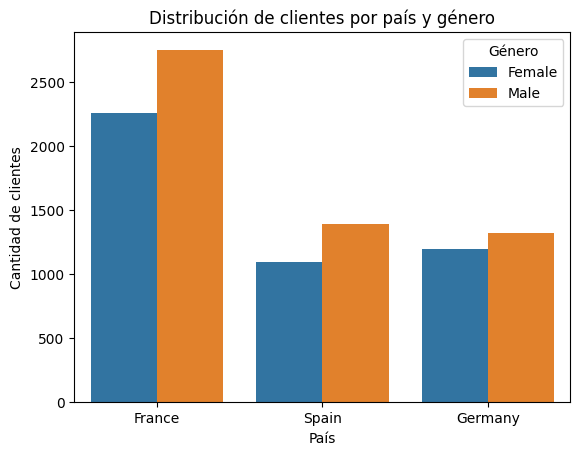

In [6]:
sns.countplot(data=bank_customer_data,x="Geography",hue="Gender")

plt.title("Distribución de clientes por país y género")
plt.xticks(["Spain","France","Germany"])
plt.xlabel("País")
plt.ylabel("Cantidad de clientes")
plt.legend(title="Género")
plt.show()

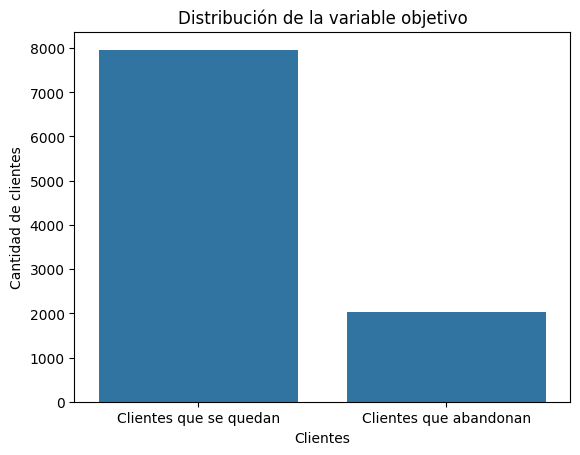

In [7]:
sns.countplot(x='Exited',data=bank_customer_data)

plt.title('Distribución de la variable objetivo')
plt.xticks([0, 1], ["Clientes que se quedan", "Clientes que abandonan"])
plt.xlabel("Clientes")
plt.ylabel("Cantidad de clientes")
plt.show()

Ninguna de las variables presenta valores nulos y no existen filas duplicadas, sin embargo tres columnas entregan datos con Dtype = String

## 4. Limpieza de datos

Eliminar columnas que no aportan información al modelo como:

- RowNumber: corresponde a un indice
- CustomerId: identificador del cliente en el banco
- Surname: apellido del clientes no aporta informacion al modelo

In [8]:
bank_customer_data = bank_customer_data.drop(columns=["RowNumber", "CustomerId", "Surname"])
bank_customer_data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
bank_customer_data.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


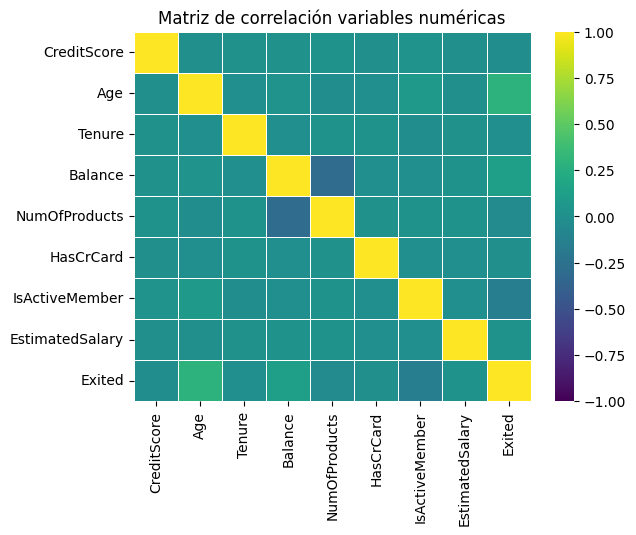

In [10]:
corr = bank_customer_data.corr(numeric_only=True)
sns.heatmap(corr,cmap="viridis",vmin=-1,vmax=1,linewidth=.5)
plt.title("Matriz de correlación variables numéricas")
plt.show()

## 5. Preprocesamiento

Codificar las columnas categoricas para el modelo de ML

In [11]:
bank_customer_data['Gender'] = bank_customer_data['Gender'].map({'Female': 1,'Male': 0})
bank_customer_data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,1,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,1,41,1,83807.86,1,0,1,112542.58,0
2,502,France,1,42,8,159660.80,3,1,0,113931.57,1
3,699,France,1,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,1,43,2,125510.82,1,1,1,79084.10,0


In [12]:
bank_customer_data = pd.get_dummies(bank_customer_data,columns=["Geography"],dtype=int)
bank_customer_data[["Geography_France", "Geography_Spain", "Geography_Germany"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Geography_France   10000 non-null  int64
 1   Geography_Spain    10000 non-null  int64
 2   Geography_Germany  10000 non-null  int64
dtypes: int64(3)
memory usage: 234.5 KB


In [13]:
# Reordenar el Dataset
bank_customer_data = bank_customer_data[["CreditScore", "Gender", "Age", "Tenure", "Balance","NumOfProducts","HasCrCard","IsActiveMember","EstimatedSalary","Geography_France","Geography_Germany","Geography_Spain","Exited"]]

In [14]:
bank_customer_data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Exited
0,619,1,42,2,0.00,1,1,1,101348.88,1,0,0,1
1,608,1,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,1,42,8,159660.80,3,1,0,113931.57,1,0,0,1
3,699,1,39,1,0.00,2,0,0,93826.63,1,0,0,0
4,850,1,43,2,125510.82,1,1,1,79084.10,0,0,1,0


Separación de los datos en conjuntos de entrenamiento y prueba.

In [15]:
X = bank_customer_data.drop('Exited', axis=1)
y = bank_customer_data['Exited']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

In [16]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((9000, 12), (1000, 12), (9000,), (1000,))

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Modelos de clasificacion

## Decision Tree

In [18]:
modelo_dt = DecisionTreeClassifier(random_state=42,class_weight="balanced")
modelo_dt.fit(X_train_scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [19]:
y_pred_dt = modelo_dt.predict(X_test_scaled)

In [20]:
print("Reporte de clasificación Decision Tree")
print(classification_report(y_test, y_pred_dt))

Reporte de clasificación Decision Tree
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       796
           1       0.49      0.51      0.50       204

    accuracy                           0.79      1000
   macro avg       0.68      0.69      0.68      1000
weighted avg       0.79      0.79      0.79      1000



[[687 109]
 [100 104]]


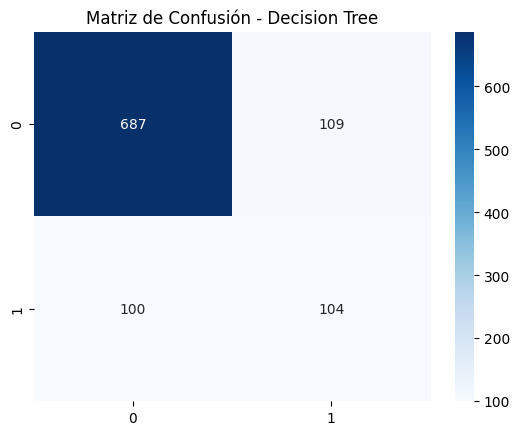

In [21]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Decision Tree")
plt.show()

## Random Forest

In [22]:
modelo_rf = RandomForestClassifier(random_state=42,class_weight="balanced")
modelo_rf.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [23]:
y_pred_rf = modelo_rf.predict(X_test_scaled)

In [24]:
print("Reporte de clasificación Random Forest")
print(classification_report(y_test, y_pred_rf))

Reporte de clasificación Random Forest
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       796
           1       0.77      0.44      0.56       204

    accuracy                           0.86      1000
   macro avg       0.82      0.70      0.74      1000
weighted avg       0.85      0.86      0.84      1000



[[770  26]
 [115  89]]


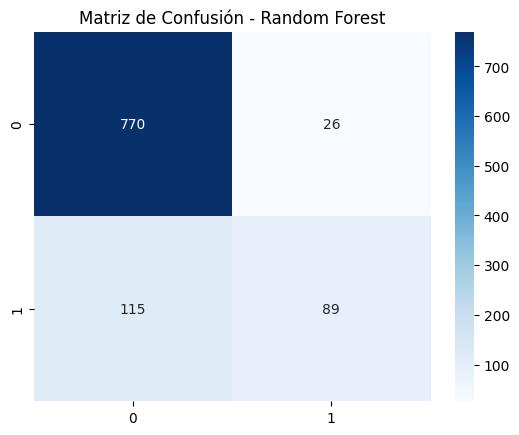

In [25]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Random Forest")
plt.show()

## Logistic Regression

In [26]:
modelo_lr = LogisticRegression(random_state=42,max_iter=1000,class_weight="balanced")
modelo_lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [27]:
y_pred_lr = modelo_lr.predict(X_test_scaled)

In [28]:
print("Reporte de clasificación Logistic Regresion")
print(classification_report(y_test, y_pred_lr))

Reporte de clasificación Logistic Regresion
              precision    recall  f1-score   support

           0       0.90      0.70      0.79       796
           1       0.37      0.68      0.48       204

    accuracy                           0.70      1000
   macro avg       0.63      0.69      0.63      1000
weighted avg       0.79      0.70      0.72      1000



[[558 238]
 [ 65 139]]


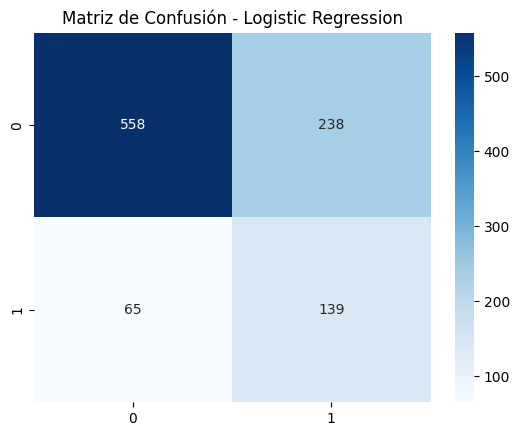

In [29]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Logistic Regression")
plt.show()

## 7. Comparacion de los modelos

In [30]:
print("Reporte de clasificación Decision Tree")
print(classification_report(y_test, y_pred_dt))
print("Reporte de clasificación Random Forest")
print(classification_report(y_test, y_pred_rf))
print("Reporte de clasificación Logistic Regression")
print(classification_report(y_test, y_pred_lr))

Reporte de clasificación Decision Tree
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       796
           1       0.49      0.51      0.50       204

    accuracy                           0.79      1000
   macro avg       0.68      0.69      0.68      1000
weighted avg       0.79      0.79      0.79      1000

Reporte de clasificación Random Forest
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       796
           1       0.77      0.44      0.56       204

    accuracy                           0.86      1000
   macro avg       0.82      0.70      0.74      1000
weighted avg       0.85      0.86      0.84      1000

Reporte de clasificación Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.70      0.79       796
           1       0.37      0.68      0.48       204

    accuracy                           0.70      1000
   ma

In [34]:
comparacion_modelos = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred_lr),accuracy_score(y_test, y_pred_dt),accuracy_score(y_test, y_pred_rf)],
    "Precision": [precision_score(y_test, y_pred_lr),precision_score(y_test, y_pred_dt),precision_score(y_test, y_pred_rf)],
    "Recall": [recall_score(y_test, y_pred_lr),recall_score(y_test, y_pred_dt),recall_score(y_test, y_pred_rf)],
    "F1-Score": [f1_score(y_test, y_pred_lr),f1_score(y_test, y_pred_dt),f1_score(y_test, y_pred_rf)]
    })

In [35]:
comparacion_modelos

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.697,0.368700,0.681373,0.478485
1,Decision Tree,0.791,0.488263,0.509804,0.498801
2,Random Forest,0.859,0.773913,0.436275,0.557994


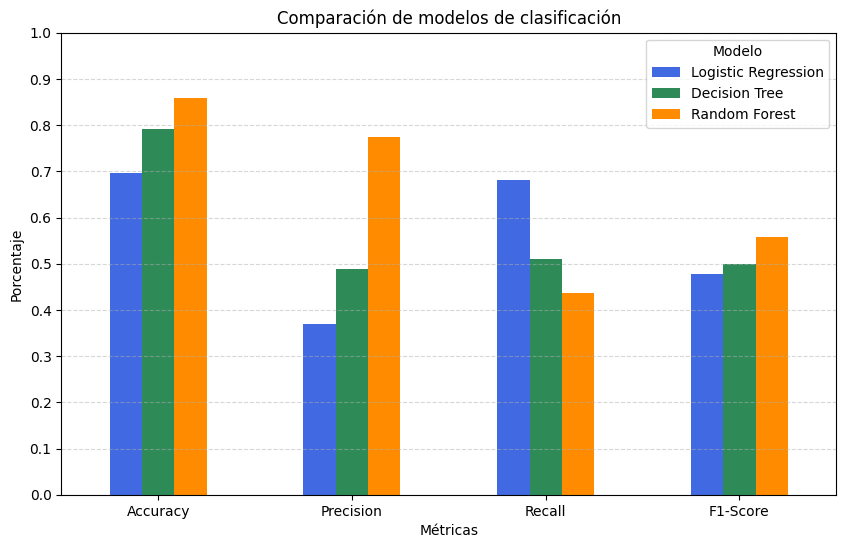

In [36]:
grafico_comparativo = comparacion_modelos.set_index("Modelo").T

grafico_comparativo.plot(kind="bar",figsize=(10,6),color=["royalblue", "seagreen", "darkorange"])

plt.title("Comparación de modelos de clasificación")
plt.xlabel("Métricas")
plt.ylabel("Porcentaje")
plt.ylim(0, 1,)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Modelo")
plt.show()

## 8. Conclusiones

### Accuracy 
Representa ¿Qué porcentaje de predicciones totales realizó correctamente el modelo?

- Random Forest 85% es el modelo con mejor desempeño, logrando la mayor cantidad de predicciones correctas.


### Precisión
De todos los clientes que el modelo predijo como posibles abandonos: ¿Cuántos realmente terminaron abandonando el banco?

- Random Forest 77% es el modelo con mejor desempeño, logrando la mayor cantidad de predicciones correctas.

### Recall
Representa De todos los clientes que realmente abandonaron el banco: ¿Cuántos logró detectar el modelo?

- Logistic Regression  con 68 % es el modelo que mas clientes en riesgo detecta


### F1-Score
Es una métrica que combina: Precision y Recall

- Random Forest Obtiene el mejor balance con 55%

Es el modelo que logra una mejor relación entre: detectar clientes que realmente podrían abandonar y reducir contactos innecesarios